# 🛍 Customer Segmentation Using RFM Analysis

**Dataset**: Online Retail Dataset (UCI)

Tools Used: `pandas~, `numpy`, `matplotlib`, `seaborn`

**Covered Topics:**

 - Data Cleaning

 - Feature Engineering (RFM)

 - Segmentation Logic

 - Visualization of Customer Groups

 - Marketing Recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("online retail.csv")
df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 2. 🔎 Data Cleaning

 - Remove missing values in `CustomerID`

 - Keep only positive quantities & prices

In [4]:
df = df.dropna(subset=['Customer ID'])
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
df['TotalPrice'] = df['Quantity'] * df['Price']
df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


## 3. 🧮 Feature Engineering (RFM Metrics)

**Recency (R):** Days since last purchase

**Frequency (F):** Total number of purchases

**Monetary (M):** Total spend

In [11]:
# Reference date (max InvoiceDate + 1 day)
import datetime as dt
ref_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# RFM metrics
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (ref_date - x.max()).days,
    'Invoice': 'count',
    'TotalPrice': 'sum'
})

rfm.rename(columns={'InvoiceDate':'Recency','InvoiceNo':'Frequency','TotalPrice':'Monetary'}, inplace=True)
rfm.head()


,Recency,Invoice,Monetary
Customer ID,,,
12346.0,326,34,77556.46
12347.0,2,253,5633.32
12348.0,75,51,2019.40
12349.0,19,175,4428.69
12350.0,310,17,334.40


## 4. 🏷 Assign RFM Scores

 - **Use quantiles (Q1, Q2, Q3)** to assign 1–4 scores for R, F, M

In [13]:
# Rename Invoice column to Frequency
rfm.rename(columns={'Invoice': 'Frequency'}, inplace=True)

# RFM Scoring
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method="first"), 4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

# Combine
rfm['RFM_Segment'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)
rfm['RFM_Score'] = (
    rfm[['R_Score','F_Score','M_Score']].astype(int).sum(axis=1)
)

print(rfm.head())


             Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Segment  \
Customer ID                                                                     
12346.0          326         34  77556.46       2       2       4         224   
12347.0            2        253   5633.32       4       4       4         444   
12348.0           75         51   2019.40       3       2       3         323   
12349.0           19        175   4428.69       4       4       4         444   
12350.0          310         17    334.40       2       1       1         211   

             RFM_Score  
Customer ID             
12346.0              8  
12347.0             12  
12348.0              8  
12349.0             12  
12350.0              4  


## 5. 🎯 Segmentation Logic

Define simple groups based on **RFM_Score:**

In [14]:
def segment_customer(score):
    if score >= 9:
        return "Champions"
    elif score >= 7:
        return "Loyal Customers"
    elif score >= 5:
        return "Potential Loyalist"
    else:
        return "At Risk"

rfm['Segment'] = rfm['RFM_Score'].apply(segment_customer)
rfm['Segment'].value_counts()


Segment
Champions             2287
Loyal Customers       1252
Potential Loyalist    1235
At Risk               1104
Name: count, dtype: int64

## 6. 📊 Visualization of Customer Segments

### Distribution of Segments

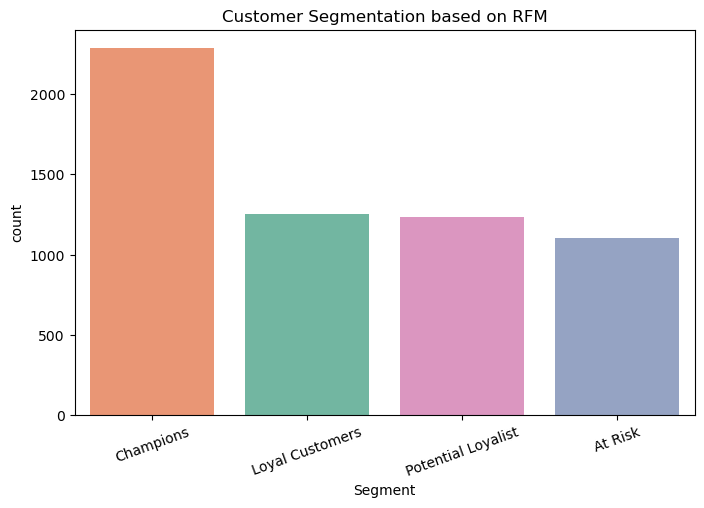

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(
    x="Segment",
    hue="Segment",   # add this
    data=rfm,
    order=rfm['Segment'].value_counts().index,
    palette="Set2",
    legend=False     # hide redundant legend
)
plt.title("Customer Segmentation based on RFM")
plt.xticks(rotation=20)
plt.show()


### Monetary by Segment

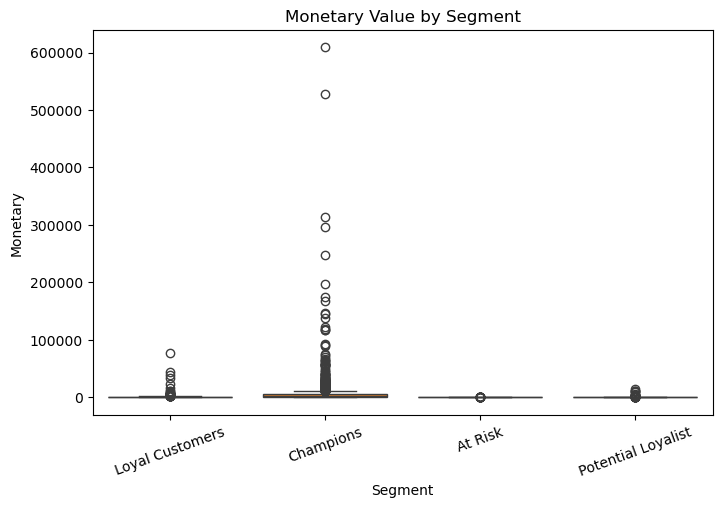

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pick a colorful palette
palette = sns.color_palette("tab10", n_colors=rfm['Segment'].nunique())

plt.figure(figsize=(8,5))
sns.boxplot(
    x="Segment",
    y="Monetary",
    hue="Segment",
    data=rfm,
    palette=palette,
    legend=False
)
plt.title("Monetary Value by Segment")
plt.xticks(rotation=20)
plt.show()



## 💡 Marketing Recommendations

| Segment            | Characteristics                       | Marketing Ideas                                      |
|--------------------|----------------------------------------|------------------------------------------------------|
| Champions          | Recent, frequent, high spenders        | VIP offers, exclusive deals, early product launches  |
| Loyal Customers    | Frequent buyers, good monetary         | Loyalty programs, membership discounts               |
| Potential Loyalist | Recent buyers, not yet frequent        | Special discounts, follow-up emails to encourage repeat purchase |
| At Risk            | Long time since last purchase, low spend | Win-back campaigns, personalized reactivation emails, discount coupons |
